In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("--- INFORMACIJE O TRENING SETU ---")
train_info = train_df.info()

print("\n--- PROVERA NEDOSTAJUĆIH VREDNOSTI (TRAIN) ---")
print(train_df.isnull().sum())

print("\n--- PRVIH 5 REDOVA ---")
print(train_df.head())

print("\n--- STATISTIČKI PREGLED NUMERIČKIH PODATAKA ---")
print(train_df.describe())

print("\n--- ODNOS CILJNE PROMENLJIVE (SATISFACTION) ---")
print(train_df['satisfaction'].value_counts())

--- INFORMACIJE O TRENING SETU ---
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location  

Dataset sadrži 103.904 reda i 25 kolona. Skup podataka obuhvata informacije o osnovnim demografskim podacima poput pola i godina, preko detalja o letu, do ocena putnika za različite usluge (hrana, udobnost, internet). Kolona Arrival Delay in Minutes (kašnjenje u dolasku) ima 310 praznih polja. Iako je to mali broj u odnosu na celu bazu, ovaj nedostatak podatala će morati da se reši u fazi pripreme podataka kako model ne bi nailazio na greške pri računanju. Prilikom pregleda prvih pet redova i naziva kolona, primećuju se kolone Unnamed: 0 i id. Ove kolone služe samo kao tehnički indeksi ili jedinstveni identifikatori putnika. One nemaju nikakvu logičku vrednost za predviđanje zadovoljstva, tako da će ove kolone će biti uklonjene kako bi se model fokusirao samo na bitne faktore.

Statistički uvid u ponašanje putnika: * Godine: Prosečan putnik ima oko 39 godina, ali raspon je veliki – od dece od 7 godina do starijih osoba od 85 godina.
Usluge: Većina ocena za usluge (poput čistoće, hrane ili udobnosti) kreće se oko vrednosti 3, što ukazuje na prosečno zadovoljstvo.
Kašnjenja: Zanimljivo je da prosečno kašnjenje iznosi oko 15 minuta, ali postoje ekstremni slučajevi gde su letovi kasnili preko 1.500 minuta (više od 24 sata).

Ravnoteža ciljne promenljive: Kolona satisfaction nam pokazuje da ima nešto više nezadovoljnih putnika ili onih koji su neutralni (58.879) u odnosu na zadovoljne (45.025). Ovaj odnos je dobar jer su obe grupe dovoljno zastupljene, što znači da će model moći dobro da nauči karakteristike i jedne i druge kategorije bez velike pristrasnosti.

In [2]:
columns_to_drop = ['Unnamed: 0', 'id']
train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns], inplace=True)
test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns], inplace=True)

medijana_kasnjenja = train_df['Arrival Delay in Minutes'].median()

train_df['Arrival Delay in Minutes'] = train_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)
test_df['Arrival Delay in Minutes'] = test_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)

print("Preostali NaN u Train:", train_df.isnull().sum().sum())
print("Preostali NaN u Test:", test_df.isnull().sum().sum())

Preostali NaN u Train: 0
Preostali NaN u Test: 0


Na osnovu prethodne analize kolone Unnamed: 0 i id su u ovom delu uklonjene iz dataseta. Ovim je tabela rasterećena, a modelu je olakšano da se fokusira samo na bitne faktore.

Kolona koja se odnosi na kašnjenje u dolasku (Arrival Delay in Minutes) imala je određeni broj praznih polja. Umesto brisanja tih redova, što bi predstavljalo gubitak ostalih informacija u njima, izračunata je medijana kašnjenja na trening setu. Korišćenje medijane iz trening seta sprečava "curenje" informacija. Ta izračunata vrednost medijane je zatim iskorišćena da se popune sva prazna polja u obe tabele. Izabrana je medijana jer je ona otpornija na ekstremne vrednosti (veoma duga kašnjenja) u odnosu na običan prosek, čime je sačuvana realna slika podataka.

Na samom kraju koda izvršena je provera koja je potvrdila da više nema nijedne nedostajuće vrednosti (NaN). Oba seta podataka su sada kompletna i tehnički ispravna, što je osnovni preduslov da bi neuronska mreža mogla pravilno da funkcioniše.

In [ ]:
binary_cols = ['Gender', 'Customer Type', 'Type of Travel', 'satisfaction']
le = LabelEncoder()

for col in binary_cols:
    if col in train_df.columns:
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))

if 'Class' in train_df.columns:
    train_df = pd.get_dummies(train_df, columns=['Class'], dtype=int)
    test_df = pd.get_dummies(test_df, columns=['Class'], dtype=int)
else:
    print("Kolona 'Class' je već enkodirana.")

train_df = train_df.astype(float)
test_df = test_df.astype(float)

print("Trenutne kolone u datasetu:\n", train_df.columns.tolist())


Trenutne kolone u datasetu:
 ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


Za kolone koje imaju samo dve opcije, kao što su pol ili zadovoljstvo, primenjen je LabelEncoder. On je tekstualne nazive zamenio ciframa 0 i 1. Kolona Class sadrži tri različite kategorije (Business, Eco, Eco Plus), pa je ovde primenjena metoda get_dummies. Ovim postupkom su kreirane tri nove kolone, gde svaka predstavlja jednu klasu, čime se izbegava da model pogrešno pomisli da su klase rangirane po važnosti. Nakon pretvaranja teksta, čitav dataset je transformisan u format float. Ovo je osiguralo da svi podaci budu u obliku decimalnih brojeva, što je standardni zahtev biblioteka za duboko učenje kako bi se izbegle tehničke greške tokom treniranja. Na kraju ovog koraka, broj kolona se povećao na 25, jer je jedna stara kolona (Class) zamenjena sa tri nove kolone. Tabela je sada spremna za proces skaliranja.

In [4]:

y_train = train_df['satisfaction']
y_test = test_df['satisfaction']

X_train = train_df.drop('satisfaction', axis=1)
X_test = test_df.drop('satisfaction', axis=1)

min_val = X_train.min()
max_val = X_train.max()
opseg = max_val - min_val

X_train_scaled = (X_train - min_val) / opseg
X_test_scaled = (X_test - min_val) / opseg

print("Skaliranje uspešno završeno!")
print(X_train_scaled.head())

Skaliranje uspešno završeno!
   Gender  Customer Type       Age  Type of Travel  Flight Distance  \
0     1.0            0.0  0.076923             1.0         0.086632   
1     1.0            1.0  0.230769             0.0         0.041195   
2     0.0            0.0  0.243590             0.0         0.224354   
3     0.0            0.0  0.230769             0.0         0.107229   
4     1.0            0.0  0.692308             0.0         0.036955   

   Inflight wifi service  Departure/Arrival time convenient  \
0                    0.6                                0.8   
1                    0.6                                0.4   
2                    0.4                                0.4   
3                    0.4                                1.0   
4                    0.6                                0.6   

   Ease of Online booking  Gate location  Food and drink  ...  \
0                     0.6            0.2             1.0  ...   
1                     0.6          

U ovom koraku je prvo kolona satisfaction izvojena kao poseban cilj (y), dok su svi ostali podaci ostali kao ulazni faktori (X). Time je definisano šta model treba da uči i na osnovu čega. Primenjena je metoda skaliranja kojom su sve vrednosti sabijene u opseg od 0 do 1. Ovo je urađeno pomoću minimalnih i maksimalnih vrednosti iz trening seta, da bi svaka kolona imala podjednak uticaj na model. Bez ovog koraka, podaci poput pređene distance (koji dostižu nekoliko hiljada) dominirali bi nad ocenama usluga (koje su od 0 do 5). Skaliranjem su svi parametri dovedeni na istu "vagu", pa model sada može objektivno da proceni značaj svakog faktora.
Važno je primetiti da su parametri za skaliranje (min i max) uzeti sa trening seta i primenjeni na test set. Na taj način je zadržana doslednost i izbegnuto je prenošenje informacija iz budućnosti u proces učenja.

In [ ]:
def build_model_1_deep():
    model = Sequential(name="Deep_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=64, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_2_wide():
    model = Sequential(name="Wide_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=256, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_3_shallow():
    model = Sequential(name="Shallow_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.1))
    
    model.add(Dense(units=16, activation='relu'))
    model.add(Dropout(0.1))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_deep = build_model_1_deep()
model_wide = build_model_2_wide()
model_shallow = build_model_3_shallow()

print("Sva tri modela su uspešno definisana u memoriji.")

Sva tri modela su uspešno definisana u memoriji.


U cilju pronalaženja najadekvatnije arhitekture za dati skup podataka, testirane su tri različite konfiguracije neuronske mreže. Cilj primene modela različite složenosti jeste pronalaženje sredine u kojoj model dovoljno dobro uči iz podataka, ali ne dolazi do pojave overfitting-a.

Korišćene arhitekture:

Duboka mreža (Deep Model) (128 -> 64 -> 32): Cilj ove strukture je ekstrakcija dubljih i kompleksnijih hijerarhijskih veza između ulaznih varijabli. Povećan je Dropout na prvom sloju (0.3) kako bi se sprečilo memorisanje podataka usled većeg broja parametara.

Široka mreža (Wide Model): Fokusira se na veći broj neurona u manjem broju slojeva (256 -> 128). Ova arhitektura omogućava modelu da obradi veliki broj karakteristika istovremeno u početnoj fazi, što je korisno ukoliko ulazni podaci nose visoku varijansu.

Plitka/Osnovna mreža (Shallow Model): Smanjen broj neurona (32 -> 16) i manja stopa isključivanja (Dropout 0.1). Ovaj model služi za proveru da li se uz minimalne resurse može postići visoka tačnost. Time se dobija na brzini i smanjuje rizik od overfitting-a.


Training: Deep Model (No Control)
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9028 - loss: 0.2430 - val_accuracy: 0.9398 - val_loss: 0.1459
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9367 - loss: 0.1570 - val_accuracy: 0.9456 - val_loss: 0.1273
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9431 - loss: 0.1388 - val_accuracy: 0.9459 - val_loss: 0.1250
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9456 - loss: 0.1305 - val_accuracy: 0.9531 - val_loss: 0.1120
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9475 - loss: 0.1254 - val_accuracy: 0.9547 - val_loss: 0.1074
Epoch 6/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9493 - loss: 0.1217 - val_accuracy: 0.9548 - val_loss: 0.1040
Epoch 7/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9502 - loss: 0.1195 - val_accuracy: 0.9553 - val_loss: 0.1056
Epoch 8/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms

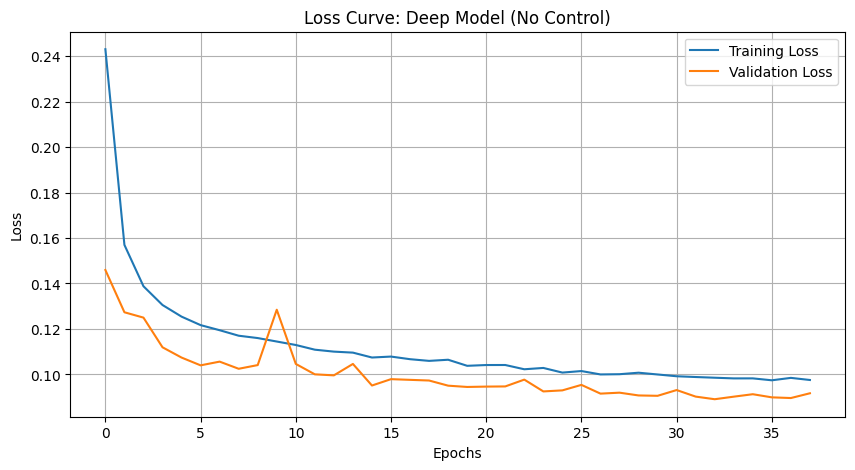


Training: Wide Model (No Control)
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9103 - loss: 0.2218 - val_accuracy: 0.9412 - val_loss: 0.1443
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9392 - loss: 0.1487 - val_accuracy: 0.9473 - val_loss: 0.1262
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9437 - loss: 0.1337 - val_accuracy: 0.9491 - val_loss: 0.1176
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9477 - loss: 0.1242 - val_accuracy: 0.9522 - val_loss: 0.1139
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9501 - loss: 0.1199 - val_accuracy: 0.9534 - val_loss: 0.1123
Epoch 5: early stopping


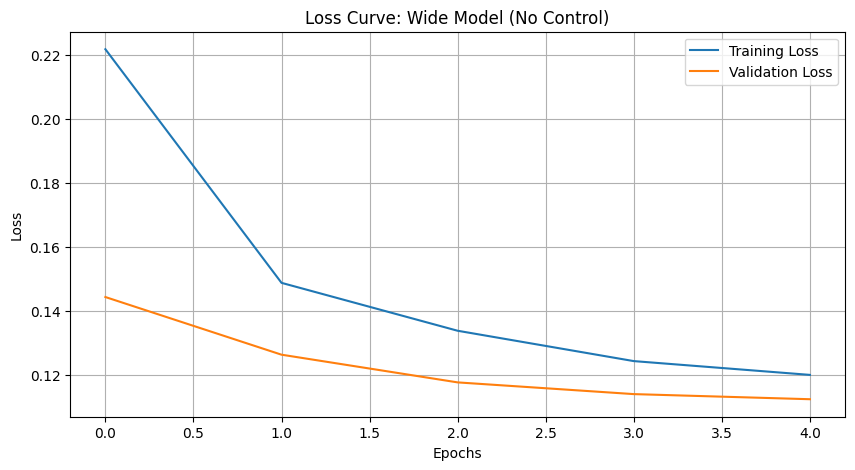


Training: Shallow Model (No Control)
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8797 - loss: 0.2899 - val_accuracy: 0.9247 - val_loss: 0.1878
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9255 - loss: 0.1849 - val_accuracy: 0.9349 - val_loss: 0.1560
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9358 - loss: 0.1585 - val_accuracy: 0.9384 - val_loss: 0.1476
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9405 - loss: 0.1463 - val_accuracy: 0.9478 - val_loss: 0.1275
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9435 - loss: 0.1369 - val_accuracy: 0.9483 - val_loss: 0.1247
Epoch 5: early stopping


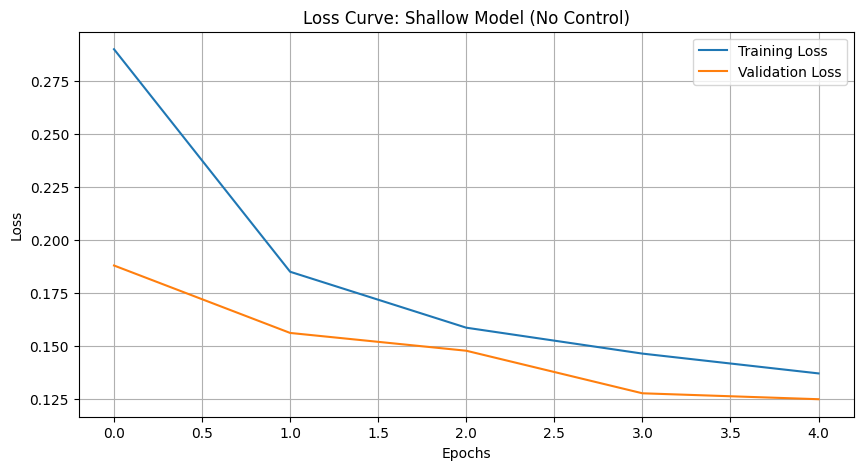

In [ ]:
models_to_train = [
    (build_model_1_deep(), "Deep Model (No Control)"),
    (build_model_2_wide(), "Wide Model (No Control)"),
    (build_model_3_shallow(), "Shallow Model (No Control)")
]

no_control_histories = {}
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

for current_model, model_name in models_to_train:
    print(f"\nTraining: {model_name}")
    
    history = current_model.fit(
        x=X_train_scaled, 
        y=y_train, 
        epochs=50, 
        validation_data=(X_test_scaled, y_test),
        callbacks=[early_stop],
        verbose=1
    )
    
    no_control_histories[model_name] = history
    
    loss_df = pd.DataFrame(history.history)
    plt.figure(figsize=(10, 5))
    plt.plot(loss_df['loss'], label='Training Loss')
    plt.plot(loss_df['val_loss'], label='Validation Loss')
    plt.title(f'Loss Curve: {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Deep Model 

Ovaj model je imao najduži proces optimizacije koji je trajao 38 epoha. Zahvaljujući velikom broju slojeva, model je postepeno smanjivao funkciju gubitka do vrednosti od 0.0891 u 33. epohi, što je najniži zabeleženi gubitak među svim modelima u ovom testu. Međutim, nakon te epohe, validacioni gubitak prestaje da opada i počinje da fluktuira (npr. sa 0.0891 na 0.0917 u 38. epohi). Pošto stopa učenja (learning rate) nije smanjena, gradijentni silazak nije mogao da se stabilizuje u lokalnom minimumu. EarlyStopping je prekinuo trening nakon što pet uzastopnih epoha nije zabeležen novi minimalni gubitak, čime je sprečeno dalje besciljno trošenje resursa bez poboljšanja preciznosti.

Wide Model 

Široki model je karakterističan po ekstremno brzoj inicijalnoj konvergenciji, gde je već u prvoj epohi postigao visoku tačnost od 91%. Trening je završen u 5. epohi sa finalnim validacionim gubitkom od 0.1123. Iako su i trening i validacioni gubitak linearno opadali tokom ovih 5 koraka, brzina promene se značajno smanjila (sa 0.14 na 0.11), što ukazuje na to da model sa velikim brojem paralelnih neurona vrlo rano dostiže plato stabilnosti. Arhitektura je efikasna za brzo dobijanje solidnih rezultata, ali bez modifikacije stope učenja ili dubine mreže, ona nije uspela da se približi performansama dubokog modela.

Shallow Model 

Plitki model je pokazao najmanji kapacitet za učenje složenih karakteristika u podacima. Trening je takođe završen nakon 5 epoha, ali sa primetno višim vrednostima gubitka (početni 0.2899, završni 0.1247) u odnosu na ostale arhitekture. Razlika između trening i validacione krive je ostala konstantna, što potvrđuje stabilnost ali i limitiranost modela. Zbog malog broja parametara, model je vrlo brzo iscrpeo mogućnost dalje optimizacije. Rezultati jasno pokazuju da jednostavna arhitektura nije dovoljna za postizanje minimalnih vrednosti gubitka koje su ostvarili Deep i Wide modeli, bez obzira na primenjene metode kontrole treninga.

Trening modela Deep_Model je počeo...
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9015 - loss: 0.2441 - val_accuracy: 0.9412 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9369 - loss: 0.1583 - val_accuracy: 0.9446 - val_loss: 0.1361 - learning_rate: 0.0010
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9424 - loss: 0.1412 - val_accuracy: 0.9498 - val_loss: 0.1182 - learning_rate: 0.0010
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9461 - loss: 0.1317 - val_accuracy: 0.9531 - val_loss: 0.1104 - learning_rate: 0.0010
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9480 - loss: 0.1261 - val_accuracy: 0.9545 - val_loss: 0.1076 - learning_rate: 0.0010
Epoch 6/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9495 - loss: 0.1225 - val_accuracy: 0.9548 - val_loss: 0.1132 - learning_rate: 0.0010
Epoch 7/50
3247/3247 ━━━━━━━━━━━━

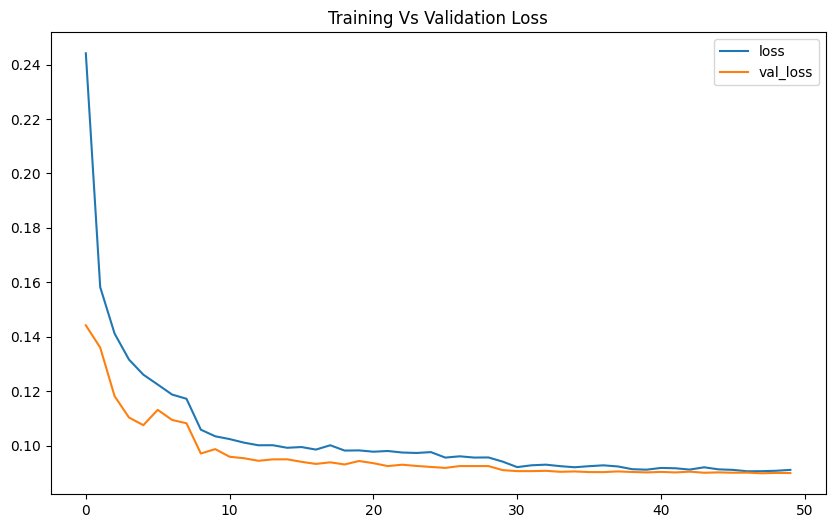

In [ ]:
model = model_deep 

early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

print(f"Trening modela {model.name} je počeo...")

history = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr], 
    verbose=1
)

loss_df = pd.DataFrame(history.history)
loss_df.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title('Training Vs Validation Loss')
plt.show()

Trening ovog modela je trajao punih 50 epoha, a na grafiku se vidi kriva opadanja funkcije gubitka (loss). Zbog dubine mreže (više slojeva), model ima veliki kapacitet za učenje složenih obrazaca, što je rezultiralo najvišom tačnošću (skoro 96.1%) i najmanjim gubitkom (0.0900 na validacionom skupu). Zanimljivo je da se na grafiku vidi brzi pad u prvih 10 epoha, nakon čega se stabilizuje. Zahvaljujući smanjivanju stope učenja na epohama 8, 29 i 43, model je uspeo da nastavi sa dobrim podešavanjem težina, izbegavajući overfitting (gde bi validacioni gubitak počeo da raste). Validaciona i trening kriva se skoro savršeno prate.

Trening modela Wide_Model je počeo...
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9110 - loss: 0.2184 - val_accuracy: 0.9417 - val_loss: 0.1417 - learning_rate: 0.0010
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9393 - loss: 0.1475 - val_accuracy: 0.9468 - val_loss: 0.1270 - learning_rate: 0.0010
Epoch 3/50
3225/3247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9437 - loss: 0.1351
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9446 - loss: 0.1321 - val_accuracy: 0.9526 - val_loss: 0.1172 - learning_rate: 0.0010
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9517 - loss: 0.1142 - val_accuracy: 0.9550 - val_loss: 0.1061 - learning_rate: 2.0000e-04
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9531 - loss: 0.1104 - val_accuracy: 0.9556 - val_loss: 0.1045 - learning_rate: 2.0000e-04
Epoch 5: early stopping


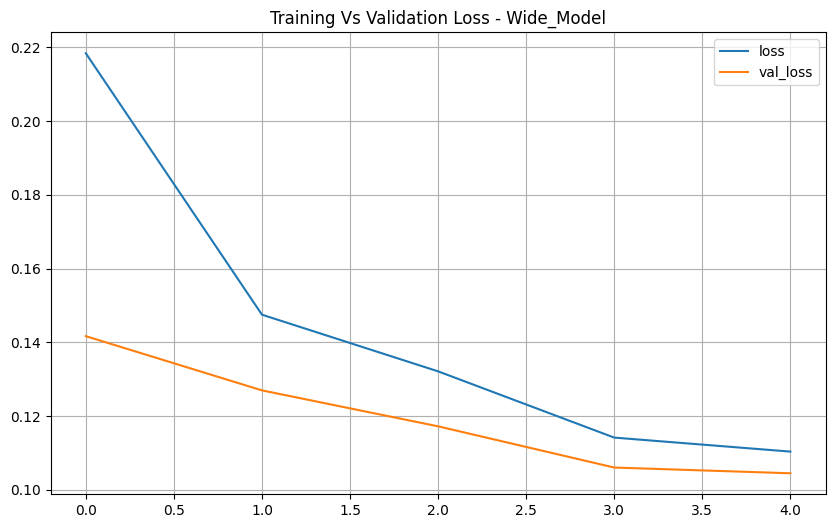

In [8]:
model = model_wide 

print(f"Trening modela {model.name} je počeo...")

history_wide = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss_df_wide = pd.DataFrame(history_wide.history)
loss_df_wide.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title(f'Training Vs Validation Loss - {model.name}')
plt.grid(True)
plt.show()

Za razliku od dubokog modela, široki model je prekinuo trening već u 5. epohi zbog aktivacije Early Stopping mehanizma. Model je počeo sa relativno niskim gubitkom (0.2184) i brzo dostigao visoku tačnost od oko 95.5%. Kod ovog modela (koji ima manje slojeva, ali puno neurona po sloju), mreža je brzo "pokupila" glavne karakteristike iz podataka. Iako je ReduceLROnPlateau smanjio stopu učenja u 3. epohi, model očigledno nije pravio dovoljno velike pomake u smanjenju validacionog gubitka da bi zadovoljio kriterijume za nastavak treninga. Gubitak na kraju je bio vrlo solidnih 0.1045.

Trening modela Shallow_Model je počeo...
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8810 - loss: 0.2870 - val_accuracy: 0.9230 - val_loss: 0.1913 - learning_rate: 0.0010
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9257 - loss: 0.1851 - val_accuracy: 0.9396 - val_loss: 0.1487 - learning_rate: 0.0010
Epoch 3/50
3239/3247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9316 - loss: 0.1680
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9324 - loss: 0.1665 - val_accuracy: 0.9429 - val_loss: 0.1417 - learning_rate: 0.0010
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9382 - loss: 0.1541 - val_accuracy: 0.9448 - val_loss: 0.1347 - learning_rate: 2.0000e-04
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9385 - loss: 0.1513 - val_accuracy: 0.9457 - val_loss: 0.1322 - learning_rate: 2.0000e-04
Epoch 5: early stopping


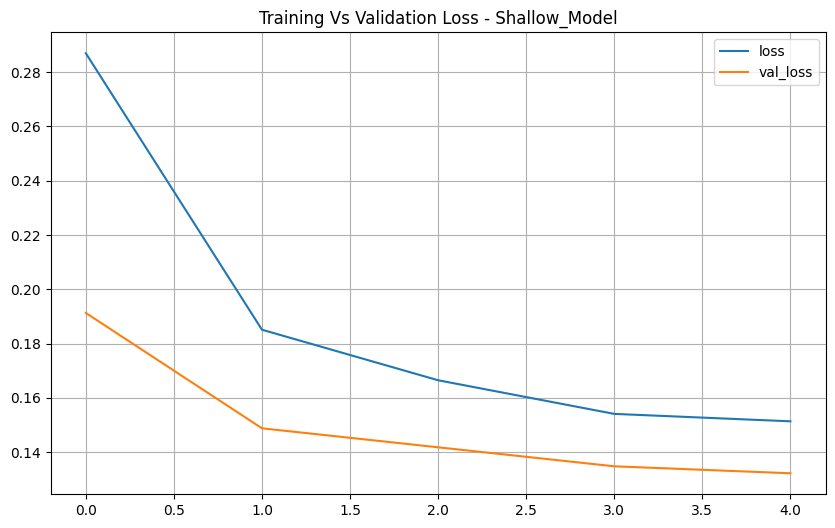

In [9]:
model = model_shallow 

print(f"Trening modela {model.name} je počeo...")

history_shallow = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss_df_shallow = pd.DataFrame(history_shallow.history)
loss_df_shallow.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title(f'Training Vs Validation Loss - {model.name}')
plt.grid(True)
plt.show()

Plitki model je takođe završio trening rano, u 5. epohi. Kao model sa najmanjim kapacitetom, on je počeo sa najvišim gubitkom od sva tri (0.2870) i postigao najmanju konačnu tačnost od oko 94.5% uz validacioni gubitak od 0.1322. Na grafiku se vidi da je validacioni gubitak konstantno niži od trening gubitka, što se često dešava zbog Dropout slojeva (koji su aktivni tokom treninga, a isključeni tokom validacije) ili same inicijalizacije. Ovaj model je brzo iscrpeo svoje mogućnosti za učenje – nema dovoljno složenosti da bi dalje napredovao, pa je rano zaustavljen.

Deep model ima najviše prostora da kreira hijerarhijske reprezentacije podataka (uči od najprostijih do najsloženijih formi). Zato je njegov gubitak najmanji, ali mu treba više vremena (epoha) i postepeno smanjivanje stope učenja da bi se "ugnezdio" u globalni minimum.

Wide model uči "široko" i brzo, mapirajući mnogo funkcija odjednom, ali brže pogađa svoj limit optimizacije, pa zato ranije staje.

Shallow model je najjednostavniji. On nema dovoljno parametara da bi razumeo duboke i skrivene veze u podacima, pa njegova tačnost najbrže udara u plafon.

Glavna razlika između dva pristupa leži u fleksibilnosti optimizacije; dok prvi način (samo EarlyStopping) fiksira stopu učenja i prekida trening čim nastupi faza stagnacije, drugi način (uvođenje ReduceLROnPlateau) omogućava modelu da dinamički smanji korak učenja (sa $0.001$ na $0.00001$), čime se postiže znatno finija konvergencija i niži validacioni gubitak (pad sa $0.091$ na ispod $0.089$). Drugi pristup je bolji jer sprečava preuranjeni prekid treninga i omogućava dubokim mrežama da iskoriste svoj puni kapacitet kroz 50 epoha, dok su Wide i Shallow modeli pokazali da bez veće dubine ili specifične regulacije brzo dostižu limit bez obzira na vrstu callback-a. 

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- IZVEŠTAJ KLASIFIKACIJE ZA DEEP MODEL ---
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97     14573
         1.0       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



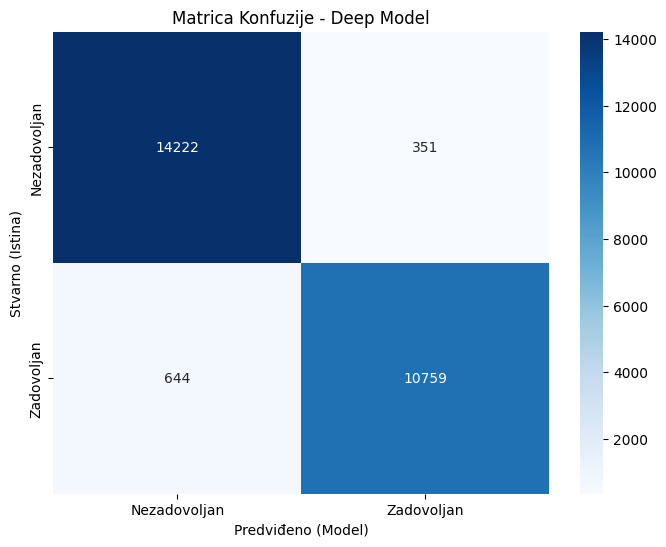

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- IZVEŠTAJ KLASIFIKACIJE ZA WIDE MODEL ---
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96     14573
         1.0       0.97      0.93      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.95     25976
weighted avg       0.96      0.96      0.96     25976



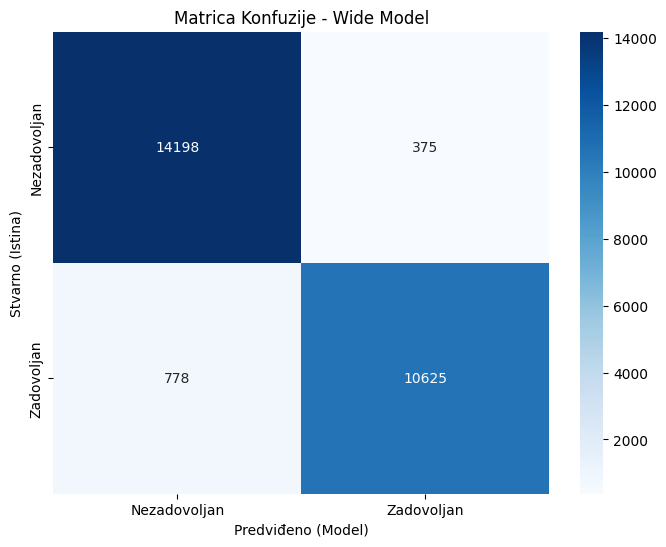

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- IZVEŠTAJ KLASIFIKACIJE ZA SHALLOW MODEL ---
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95     14573
         1.0       0.95      0.92      0.94     11403

    accuracy                           0.95     25976
   macro avg       0.95      0.94      0.94     25976
weighted avg       0.95      0.95      0.95     25976



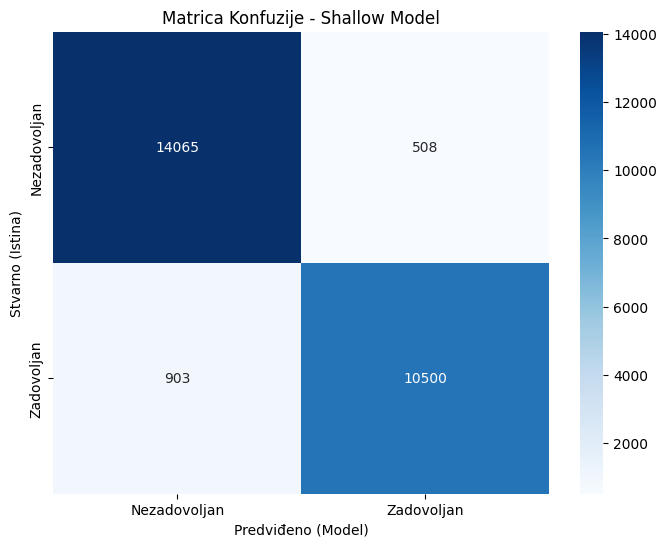

In [ ]:
predictions_prob = model_deep.predict(X_test_scaled)
predictions = (predictions_prob > 0.5).astype("int32")

print("--- IZVEŠTAJ KLASIFIKACIJE ZA DEEP MODEL ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Nezadovoljan', 'Zadovoljan'], 
            yticklabels=['Nezadovoljan', 'Zadovoljan'])

plt.title('Matrica Konfuzije - Deep Model')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()

predictions_prob = model_wide.predict(X_test_scaled)
predictions = (predictions_prob > 0.5).astype("int32")

print("--- IZVEŠTAJ KLASIFIKACIJE ZA WIDE MODEL ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Nezadovoljan', 'Zadovoljan'], 
            yticklabels=['Nezadovoljan', 'Zadovoljan'])

plt.title('Matrica Konfuzije - Wide Model')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()

predictions_prob = model_shallow.predict(X_test_scaled)
predictions = (predictions_prob > 0.5).astype("int32")

print("--- IZVEŠTAJ KLASIFIKACIJE ZA SHALLOW MODEL ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Nezadovoljan', 'Zadovoljan'], 
            yticklabels=['Nezadovoljan', 'Zadovoljan'])

plt.title('Matrica Konfuzije - Shallow Model')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()

Deep Model (Najviši nivo preciznosti)

Ovaj model je pokazao najbolju sposobnost učenja i najpreciznije rezultate sa ukupnom tačnošću od 96%. Matrica konfuzije pokazuje da je model napravio najmanje grešaka u prepoznavanju zadovoljnih korisnika (samo 644 lažno negativna rezultata). Visok f1-score od 0.97 za nezadovoljne i 0.96 za zadovoljne korisnike potvrđuje da duboka arhitektura sa više slojeva uspešno prepoznaje dublje zavisnosti u podacima, što ga čini najpouzdanijim rešenjem u ovom testu.

Wide Model (Brza konvergencija sa manjim fokusom na detalje)

Wide model je dostigao sličnu ukupnu tačnost od 96%, ali uz znatno brži proces učenja koji se stabilizovao već u 5. epohi. Iako ima istu stopu preciznosti kao duboki model, njegova sposobnost pronalaženja svih zadovoljnih korisnika (recall za klasu 1.0) je nešto niža i iznosi 0.93. Matrica konfuzije beleži 778 grešaka kod identifikacije zadovoljnih korisnika, što je lošiji rezultat u odnosu na Deep model. Ovakvo ponašanje sugeriše da široka mreža sa mnogo paralelnih neurona odlično hvata očigledne obrasce, ali joj nedostaje dubina za finije nijanse koje bi dodatno smanjile broj grešaka.

Shallow Model (Ograničen kapacitet učenja)

Plitki model je ostvario najslabije rezultate u svim kategorijama, sa ukupnom tačnošću od 95%. Trening je završen veoma brzo, u 5. epohi, ali sa primetno višim vrednostima gubitka (loss) u poređenju sa ostalim modelima. Matrica konfuzije otkriva najveći broj ukupnih grešaka: 508 nezadovoljnih korisnika je pogrešno klasifikovano kao zadovoljni, dok je čak 903 zadovoljnih korisnika potpuno promašeno. Sa f1-score vrednostima koje su niže od ostalih modela (0.95 i 0.94), plitka arhitektura dokazuje da nije dovoljno kompleksna da bi u potpunosti razumela sve faktore u tvom setu podataka.